<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Early%20Stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Early Stopping

Ebben a notebookban az **early stopping** regularizációs technikát vizsgáljuk.

## Tartalomjegyzék

1. Early stopping motiváció
2. Validációs hiba monitorozása
3. Patience és delta
4. Implementáció
5. Best model mentése

## 1. Early stopping motiváció

### Overfitting időbeli alakulása

| Fázis | Train loss | Val loss | Állapot |
|-------|------------|----------|--------|
| Korai | Csökken | Csökken | Underfitting |
| Optimális | Csökken | Minimum | Legjobb |
| Késői | Csökken | Növekszik | Overfitting |

### Early stopping elve

Állítsuk meg a tanítást, mielőtt a validációs hiba növekedni kezd!

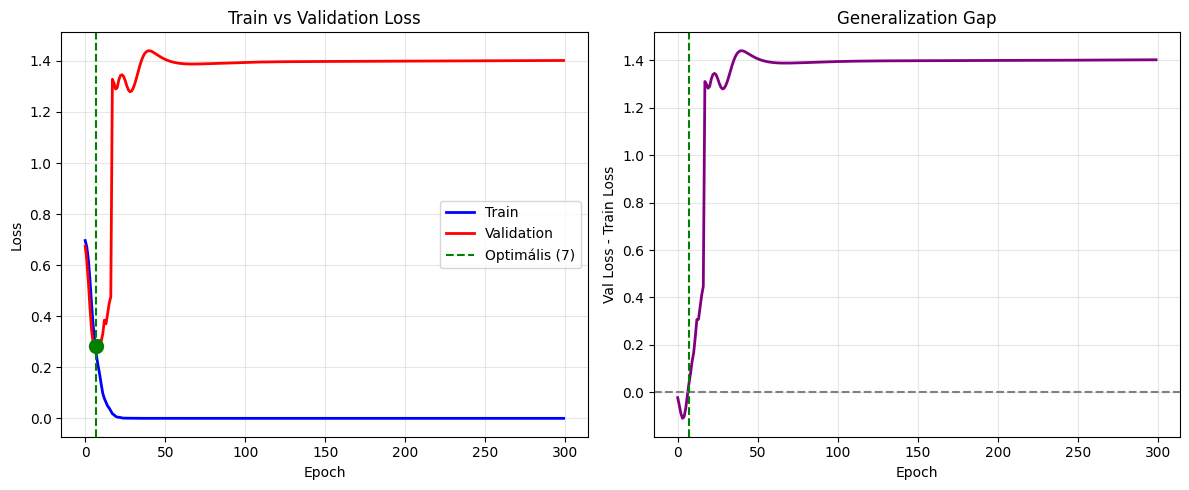

Legjobb epoch: 7
Legjobb val loss: 0.2826
Végső val loss: 1.4016


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from copy import deepcopy

np.random.seed(42)
torch.manual_seed(42)

# Adat
X, y = make_classification(n_samples=500, n_features=20, n_informative=10,
                          n_redundant=5, random_state=42)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

# Overfitting demonstráció
def train_without_early_stopping(epochs=300):
    torch.manual_seed(42)
    model = nn.Sequential(
        nn.Linear(20, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1),
        nn.Sigmoid()
    )

    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Train
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t).squeeze()
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        # Validation
        model.eval()
        with torch.no_grad():
            val_out = model(X_val_t).squeeze()
            val_loss = criterion(val_out, y_val_t)
            val_losses.append(val_loss.item())

    return train_losses, val_losses

train_losses, val_losses = train_without_early_stopping()

# Vizualizáció
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-', linewidth=2, label='Train')
plt.plot(val_losses, 'r-', linewidth=2, label='Validation')

# Optimális pont
best_epoch = np.argmin(val_losses)
plt.axvline(x=best_epoch, color='g', linestyle='--', label=f'Optimális ({best_epoch})')
plt.scatter([best_epoch], [val_losses[best_epoch]], c='g', s=100, zorder=5)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Overfitting gap
gap = np.array(val_losses) - np.array(train_losses)
plt.plot(gap, 'purple', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--')
plt.axvline(x=best_epoch, color='g', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Val Loss - Train Loss')
plt.title('Generalization Gap')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Legjobb epoch: {best_epoch}")
print(f"Legjobb val loss: {val_losses[best_epoch]:.4f}")
print(f"Végső val loss: {val_losses[-1]:.4f}")

## 2. Validációs hiba monitorozása

### Monitorozási stratégiák

| Metrika | Mikor használd |
|---------|---------------|
| Val loss | Általános |
| Val accuracy | Klasszifikáció |
| Val F1 | Kiegyensúlyozatlan |
| Custom | Domain-specifikus |

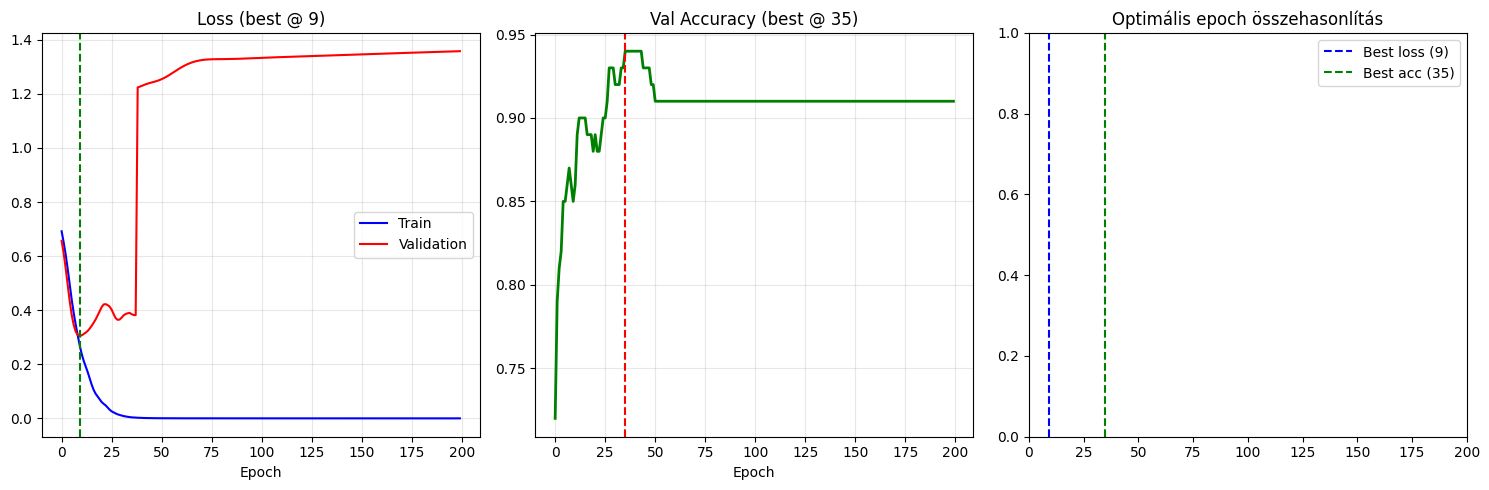

In [2]:
# Különböző metrikák monitorozása

def train_with_metrics(epochs=200):
    torch.manual_seed(42)
    model = nn.Sequential(
        nn.Linear(20, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1),
        nn.Sigmoid()
    )

    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t).squeeze()
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        history['train_loss'].append(loss.item())

        model.eval()
        with torch.no_grad():
            val_out = model(X_val_t).squeeze()
            val_loss = criterion(val_out, y_val_t)
            val_preds = (val_out > 0.5).float()
            val_acc = (val_preds == y_val_t).float().mean()

            history['val_loss'].append(val_loss.item())
            history['val_acc'].append(val_acc.item())

    return history

history = train_with_metrics()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Loss
axes[0].plot(history['train_loss'], 'b-', label='Train')
axes[0].plot(history['val_loss'], 'r-', label='Validation')
best_loss_epoch = np.argmin(history['val_loss'])
axes[0].axvline(x=best_loss_epoch, color='g', linestyle='--')
axes[0].set_title(f'Loss (best @ {best_loss_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['val_acc'], 'g-', linewidth=2)
best_acc_epoch = np.argmax(history['val_acc'])
axes[1].axvline(x=best_acc_epoch, color='r', linestyle='--')
axes[1].set_title(f'Val Accuracy (best @ {best_acc_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)

# Összehasonlítás
axes[2].axvline(x=best_loss_epoch, color='blue', linestyle='--', label=f'Best loss ({best_loss_epoch})')
axes[2].axvline(x=best_acc_epoch, color='green', linestyle='--', label=f'Best acc ({best_acc_epoch})')
axes[2].set_title('Optimális epoch összehasonlítás')
axes[2].legend()
axes[2].set_xlim(0, len(history['val_loss']))

plt.tight_layout()
plt.show()

## 3. Patience és delta

### Paraméterek

| Paraméter | Jelentés | Tipikus érték |
|-----------|----------|---------------|
| patience | Hány epoch javulás nélkül | 5-20 |
| min_delta | Minimális javulás | 0.001 |
| mode | min (loss) vagy max (acc) | min |

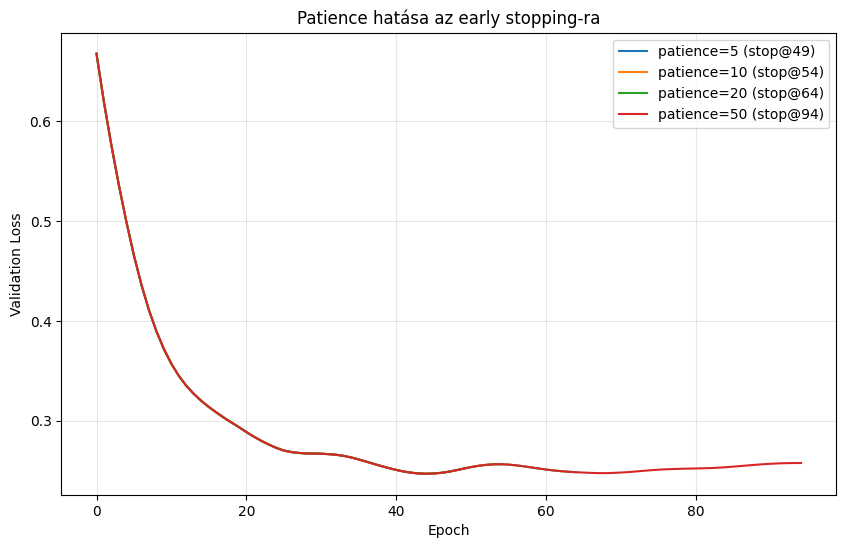

In [3]:
class EarlyStopping:
    """
    Early stopping implementáció.
    """
    def __init__(self, patience=10, min_delta=0.0, mode='min', verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.verbose = verbose

        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_epoch = 0

    def __call__(self, score, epoch):
        if self.mode == 'min':
            score = -score

        if self.best_score is None:
            self.best_score = score
            self.best_epoch = epoch
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_epoch = epoch
            self.counter = 0

        return self.early_stop

# Patience hatásának vizsgálata
patience_values = [5, 10, 20, 50]

fig, ax = plt.subplots(figsize=(10, 6))

for patience in patience_values:
    torch.manual_seed(42)
    model = nn.Sequential(
        nn.Linear(20, 64),
        nn.ReLU(),
        nn.Linear(64, 1),
        nn.Sigmoid()
    )
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()

    early_stopping = EarlyStopping(patience=patience, verbose=False)
    val_losses = []
    stopped_epoch = 200

    for epoch in range(200):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t).squeeze()
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_out = model(X_val_t).squeeze()
            val_loss = criterion(val_out, y_val_t)
            val_losses.append(val_loss.item())

        if early_stopping(val_loss.item(), epoch):
            stopped_epoch = epoch
            break

    ax.plot(val_losses, label=f'patience={patience} (stop@{stopped_epoch})')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Patience hatása az early stopping-ra')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 4. Implementáció

### Teljes tanítási loop

Early stopping @ epoch 21
Best epoch: 6


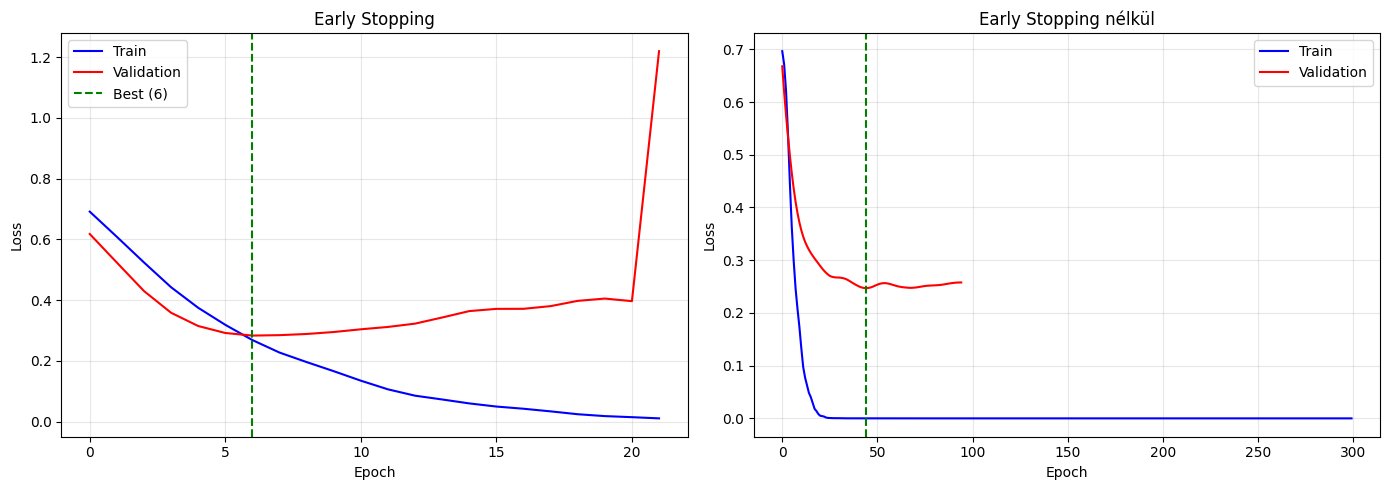

In [5]:
def train_with_early_stopping(patience=10, min_delta=0.001, max_epochs=300):
    torch.manual_seed(42)
    model = nn.Sequential(
        nn.Linear(20, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 1),
        nn.Sigmoid()
    )

    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()

    early_stopping = EarlyStopping(patience=patience, min_delta=min_delta, verbose=False)
    best_model_state = None
    best_val_loss = float('inf')

    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(max_epochs):
        # Train
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t).squeeze()
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        history['train_loss'].append(loss.item())

        # Validation
        model.eval()
        with torch.no_grad():
            val_out = model(X_val_t).squeeze()
            val_loss = criterion(val_out, y_val_t)
            history['val_loss'].append(val_loss.item())

        # Best model mentése
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = deepcopy(model.state_dict())

        # Early stopping check
        if early_stopping(val_loss.item(), epoch):
            print(f"Early stopping @ epoch {epoch}")
            print(f"Best epoch: {early_stopping.best_epoch}")
            break

    # Best model visszatöltése
    model.load_state_dict(best_model_state)

    return model, history, early_stopping.best_epoch

# Tanítás early stopping-gal
model_es, history_es, best_epoch = train_with_early_stopping(patience=15)

# Összehasonlítás
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Early stopping
axes[0].plot(history_es['train_loss'], 'b-', label='Train')
axes[0].plot(history_es['val_loss'], 'r-', label='Validation')
axes[0].axvline(x=best_epoch, color='g', linestyle='--', label=f'Best ({best_epoch})')
axes[0].set_title('Early Stopping')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Nélküle
axes[1].plot(train_losses, 'b-', label='Train')
axes[1].plot(val_losses, 'r-', label='Validation')
axes[1].axvline(x=np.argmin(val_losses), color='g', linestyle='--')
axes[1].set_title('Early Stopping nélkül')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Best model mentése

### Model checkpoint

| Stratégia | Leírás |
|-----------|--------|
| Best only | Csak a legjobb modell |
| Periodic | Minden N epoch |
| All | Minden epoch |

In [ ]:
class ModelCheckpoint:
    """
    Model checkpoint mentő.
    """
    def __init__(self, filepath='best_model.pt', mode='min', verbose=True):
        self.filepath = filepath
        self.mode = mode
        self.verbose = verbose
        self.best_score = None
        self.best_model_state = None

    def __call__(self, score, model):
        if self.mode == 'min':
            score = -score

        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.best_model_state = deepcopy(model.state_dict())
            if self.verbose:
                print(f"Új legjobb modell mentve (score: {-score if self.mode=='min' else score:.4f})")
            return True
        return False

    def load_best(self, model):
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)
        return model

# Használat
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(20, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCELoss()
early_stopping = EarlyStopping(patience=10, verbose=False)
checkpoint = ModelCheckpoint(verbose=True)

for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t).squeeze()
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_out = model(X_val_t).squeeze()
        val_loss = criterion(val_out, y_val_t)

    checkpoint(val_loss.item(), model)

    if early_stopping(val_loss.item(), epoch):
        print(f"\nEarly stopping @ epoch {epoch}")
        break

# Best model visszatöltése
model = checkpoint.load_best(model)

# Teszt
model.eval()
with torch.no_grad():
    test_out = model(X_test_t).squeeze()
    test_preds = (test_out > 0.5).float()
    test_acc = (test_preds == y_test_t).float().mean()
    print(f"\nTest accuracy: {test_acc.item():.4f}")

## Összefoglalás

### Early stopping:

| Tulajdonság | Leírás |
|-------------|--------|
| Cél | Overfitting megelőzése |
| Monitorozás | Validációs metrika |
| Megállás | Patience után |

### Paraméterek:

| Paraméter | Hatás |
|-----------|-------|
| patience ↑ | Több epoch, kockázatosabb |
| patience ↓ | Korai megállás, biztonságosabb |
| min_delta ↑ | Csak nagy javulás számít |

### Best practices:

1. Mindig mentsd a legjobb modellt
2. Használj validációs halmazt
3. Patience 5-20 között